In [2]:
import matplotlib.pyplot as plt
import torch
import numpy as np

In [3]:
def f_grad(x):
    return 2*x + 4

In [4]:
def gradient_descent(lr, iterations=100):
    x = 10.0
    path = []
    for _ in range(iterations):
        path.append(x)
        x = x - lr * f_grad(x)
    return path

In [5]:
rates = [0.01, 0.1, 1.1]
labels = ["η = 0.01 (Small)", "η = 0.1 (Optimal)", "η = 1.1 (Unstable)"]

In [6]:
def plot():
    
    plt.figure(figsize=(10, 4.5))
    path = gradient_descent(0.01)
    plt.plot(path, label="eta = 0.01 (small)")
    plt.legend()
    plt.show()
    
    path = gradient_descent(0.1)
    plt.plot(path, label="eta = 0.1 (optimal)")
    plt.legend()
    plt.show()
    
    path = gradient_descent(1.1)
    plt.plot(path, label="eta = 1.1 (unstable)")
    plt.legend()
    plt.show()

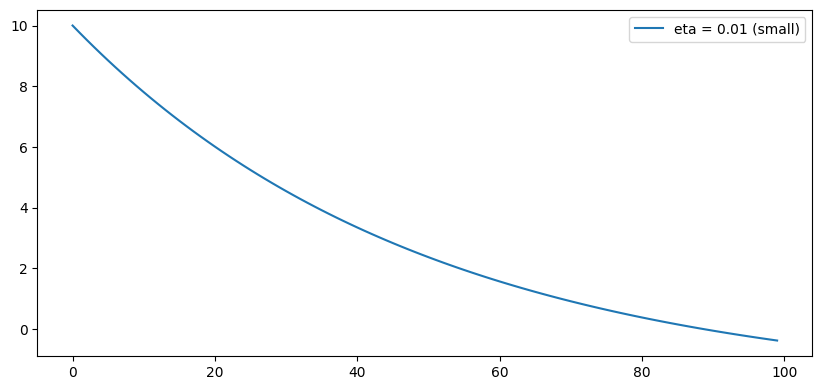

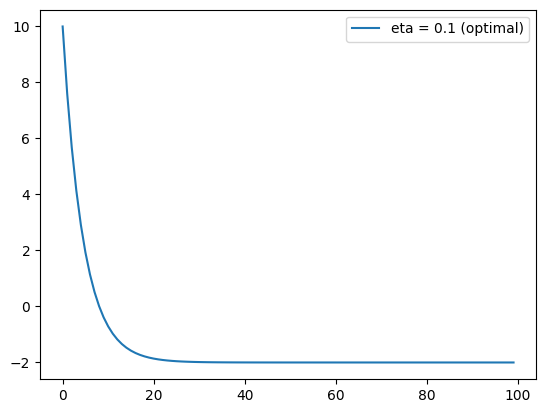

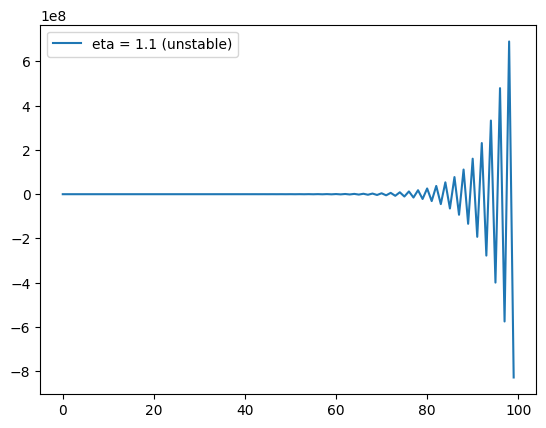

In [7]:
plot()

In [8]:
def loss_fn(x):
    return x**4 - 5*x**2 + 4*x

In [9]:
def run_optimizer(optimizer_class, start_x, lr=0.01, steps=100):
    x = torch.tensor(start_x, requires_grad=True)
    optimizer = optimizer_class([x], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(x)
        loss.backward()
        optimizer.step()

    return x.item()

In [10]:
points = np.linspace(-2, 2, 5)
res1 = []
res2 = []
res3 = []

In [11]:
for start in points:
    print(f"\nx = {start}")
    a = run_optimizer(torch.optim.SGD, start)
    print("SGD     :", a)
    res1.append(a)
    b = run_optimizer(torch.optim.RMSprop, start)
    print("RMSProp :", b)
    res2.append(b)
    c = run_optimizer(torch.optim.Adam, start)
    print("Adam    :", c)
    res3.append(c)



x = -2.0
SGD     : -1.752332176794029
RMSProp : -1.7523321767940239
Adam    : -1.752950582412219

x = -1.0
SGD     : -1.7523321767939684
RMSProp : -1.7523234455888572
Adam    : -1.7325471422790133

x = 0.0
SGD     : -1.7523321767897626
RMSProp : -1.7269667177132109
Adam    : -1.1585398035495247

x = 1.0
SGD     : 1.3200058180266898
RMSProp : 1.3200117334463222
Adam    : 1.319541964996789

x = 2.0
SGD     : 1.3200146340999792
RMSProp : 1.3234576129113595
Adam    : 1.4045795511250725


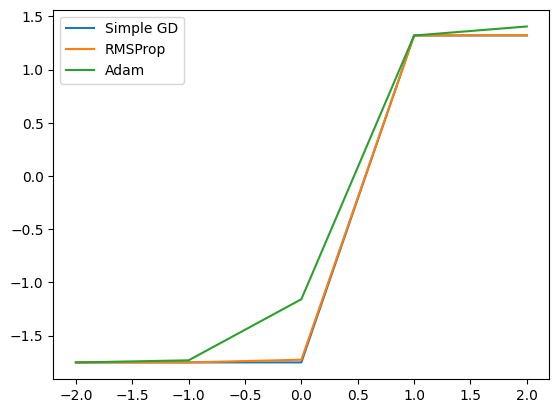

In [12]:
plt.plot(points, res1, label = "Simple GD")
plt.plot(points, res2, label = "RMSProp")
plt.plot(points, res3, label = "Adam")
plt.legend()
plt.show()